In [1]:
from nuscenes import NuScenes
from main_gemini import extract_scene_data

/mnt/09c36709-cf37-447b-8031-6e66a01e6437/Temp Projects/OpenEMMA/openemma/YOLO3D/utils/general.py:27: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg
/mnt/09c36709-cf37-447b-8031-6e66a01e6437/Temp Projects/OpenEMMA/env/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/mnt/09c36709-cf37-447b-8031-6e66a01e6437/Temp Projects/OpenEMMA/env/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`

# Load Nuscene dataset and extract scene details

In [2]:
nusc_version = 'v1.0-mini'
nusc_dataroot = 'datasets/NuScenes'

nusc = NuScenes(version=nusc_version, dataroot=nusc_dataroot)


Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.380 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.


In [3]:
for scene in nusc.scene:
    print(f"Scene {scene['name']} has {scene['nbr_samples']} samples.")

Scene scene-0061 has 39 samples.
Scene scene-0103 has 40 samples.
Scene scene-0553 has 41 samples.
Scene scene-0655 has 41 samples.
Scene scene-0757 has 41 samples.
Scene scene-0796 has 40 samples.
Scene scene-0916 has 41 samples.
Scene scene-1077 has 41 samples.
Scene scene-1094 has 40 samples.
Scene scene-1100 has 40 samples.


In [4]:
selected_scene = next((s for s in nusc.scene if s["name"] == "scene-0103"), None)

print(f"Selected scene: {selected_scene['name']} with {selected_scene['nbr_samples']} samples.")

Selected scene: scene-0103 with 40 samples.


In [5]:
front_camera_images, ego_poses, camera_params = extract_scene_data(
    nusc=nusc,
    first_sample_token=selected_scene["first_sample_token"],
    last_sample_token=selected_scene["last_sample_token"],
)

print(f"Extracted {len(front_camera_images)} front camera images.")
print(f"Extracted {len(ego_poses)} ego poses.")
print(f"Extracted {len(camera_params)} camera parameters.")

Extracted 40 front camera images.
Extracted 40 ego poses.
Extracted 40 camera parameters.


In [6]:
ego_poses[0]

{'token': '4f5e35aa6c6a426ca945e206fb2f4921',
 'timestamp': 1533151603512404,
 'rotation': [-0.9687876119182126,
  -0.004506968075376869,
  -0.00792272203393983,
  0.24772460658591755],
 'translation': [599.849775495386, 1647.6411294309523, 0.0]}

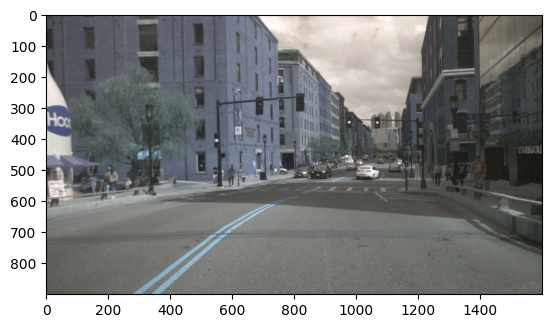

In [9]:
import base64
import matplotlib.pyplot as plt
import cv2
import numpy as np

img_bytes = base64.b64decode(front_camera_images[0])
img = cv2.imdecode(
    np.frombuffer(
        img_bytes,
        dtype=np.uint8
    ),
    cv2.IMREAD_COLOR
)

plt.imshow(img)


0: 384x640 18 cars, 69.6ms
Speed: 4.7ms preprocess, 69.6ms inference, 65.4ms postprocess per image at shape (1, 3, 384, 640)


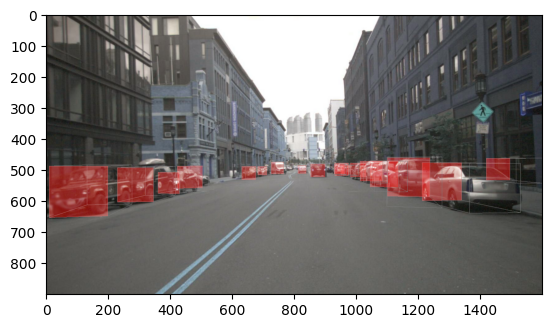

In [44]:
from openemma.YOLO3D.inference import yolo3d_nuScenes

img = yolo3d_nuScenes(img, calib=camera_params[0])[0]

plt.imshow(img)

In [14]:
camera_params[0]

{'token': 'd3ab655f3cc540a88491ec218751f9c6',
 'sensor_token': '725903f5b62f56118f4094b46a4470d8',
 'translation': [1.72200568478, 0.00475453292289, 1.49491291905],
 'rotation': [0.5077241387638071,
  -0.4973392230703816,
  0.49837167536166627,
  -0.4964832014373754],
 'camera_intrinsic': [[1252.8131021185304, 0.0, 826.588114781398],
  [0.0, 1252.8131021185304, 469.9846626224581],
  [0.0, 0.0, 1.0]]}

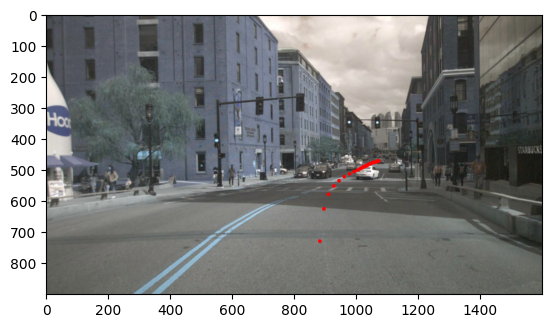

In [31]:
from utils import ProjectWorldToImage

primary_pose = ego_poses[0]
all_points3d_img = []

for i in range(1, len(ego_poses)):
    points3d_world = ego_poses[i]['translation']
    
    points3d_img = ProjectWorldToImage([points3d_world], camera_params[i], primary_pose)
    all_points3d_img.append(*points3d_img)

    cv2.circle(img, tuple(all_points3d_img[-1].astype(int)), radius=6, color=(255, 0, 0), thickness=-1)

plt.imshow(img)


In [43]:
img_bytes = base64.b64decode(front_camera_images[0])
first_img = cv2.imdecode(np.frombuffer(img_bytes, dtype=np.uint8), cv2.IMREAD_COLOR)
height, width, _ = first_img.shape

video_writer = cv2.VideoWriter(
    'future_pos_video_output.mp4',
    cv2.VideoWriter_fourcc(*'mp4v'),
    5,
    (width, height)
)

for current_image_indx in range(len(front_camera_images)):
    img_bytes = base64.b64decode(front_camera_images[current_image_indx])
    img = cv2.imdecode(
        np.frombuffer(
            img_bytes,
            dtype=np.uint8
        ),
        cv2.IMREAD_COLOR
    )

    for future_image_indx in range(current_image_indx + 1, len(ego_poses)):
        future_point_world = ego_poses[future_image_indx]['translation']
        future_point_img_array = ProjectWorldToImage([future_point_world], camera_params[future_image_indx], ego_poses[current_image_indx])
        
        if len(future_point_img_array) > 0:
            cv2.circle(img, tuple(future_point_img_array[0].astype(int)), radius=6, color=(255, 0, 0), thickness=-1)

    video_writer.write(img)

video_writer.release()